In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import gym
import d4rl
import argparse
import pickle
import sys
import tqdm
import importlib
import os
from matplotlib import pyplot as plt

from common.normalizer import StandardNormalizer
# sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath(__file__))))
from common.normalizer import StandardNormalizer
from common import util
from models.transition_model import TransitionModel
from models.d4rl_world_model import D4RLWorldModel
from common.buffer import ReplayBuffer
from common.functional import dict_batch_generator
from scoring import crps_evaluation



No module named 'flow'
/home/ubuntu/miniconda3/envs/mopo/lib/python3.8/site-packages/glfw/__init__.py:917: GLFWError: (65550) b'X11: The DISPLAY environment variable is missing'
  warnings.warn(message, GLFWError)
No module named 'carla'
pybullet build time: Jan 29 2025 23:19:57


RuntimeError: module compiled against API version 0x10 but this version of numpy is 0xe . Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem .

numpy.core.multiarray failed to import


In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# data_path = "/abiomed/intermediate_data_d4rl/hopper-expert-v0_noisy_0.05_unnorm.pkl"
data_path = ""
env_name = 'hopper-expert-v0'
env = gym.make(env_name)
if data_path == "":
    dataset = d4rl.qlearning_dataset(env)
else:
    print('loading')
    with open(data_path, 'rb') as f:
        dataset = pickle.load(f)
    dataset = {key: torch.tensor(dataset[key], dtype = torch.float32) for key in dataset.keys()}
# obs_normalizer = StandardNormalizer()
# act_normalizer = StandardNormalizer()
# obs_normalizer.update(dataset['observations'])
# act_normalizer.update(dataset["actions"])

# dataset['observations'] = obs_normalizer.transform(dataset['observations'])
# dataset['actions']  = act_normalizer.transform(dataset["actions"])


/home/ubuntu/miniconda3/envs/mopo/lib/python3.8/site-packages/gym/envs/registration.py:505: UserWarning: WARN: The environment hopper-expert-v0 is out of date. You should consider upgrading to version `v2` with the environment ID `hopper-expert-v2`.
  logger.warn(
/home/ubuntu/miniconda3/envs/mopo/lib/python3.8/site-packages/d4rl/gym_mujoco/gym_envs.py:13: UserWarning: This environment is deprecated. Please use the most recent version of this environment.
  offline_env.OfflineEnv.__init__(self, **kwargs)
/home/ubuntu/miniconda3/envs/mopo/lib/python3.8/site-packages/gym/spaces/box.py:78: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")
load datafile:   0%|          | 0/5 [00:00<?, ?it/s]

load datafile: 100%|██████████| 5/5 [00:00<00:00, 13.38it/s]


In [3]:
obs_shape = env.observation_space.shape
action_dim = np.prod(env.action_space.shape)   

offline_buffer = ReplayBuffer(
            buffer_size=len(dataset["observations"]),
            obs_shape=obs_shape,
            obs_dtype=np.float32,
            action_dim=action_dim,
            action_dtype=np.float32
        )

offline_buffer.load_dataset(dataset)

In [4]:
transition_params= {
        "model_batch_size": 256,
        "use_weight_decay": True,
        "optimizer_class": "Adam",
        "learning_rate": 0.001,
        "holdout_ratio": 0.2,
        "inc_var_loss": True,
        "model": {
            "hidden_dims": [200, 200, 200, 200],
            "decay_weights": [0.000025, 0.00005, 0.000075, 0.000075, 0.0001],
            "act_fn": "swish",
            "out_act_fn": "identity",
            "num_elite": 5,
            "ensemble_size": 7
        }
}

In [5]:
mopo_params = {
        "max_epoch": 125,
        "rollout_batch_size": 50000,
        "rollout_mini_batch_size": 10000,
        "model_retain_epochs": 1,
        "num_env_steps_per_epoch": 1000,
        "train_model_interval": 250,
        "max_trajectory_length": 1000,
        "eval_interval": 1000,
        "num_eval_trajectories": 10,
        "snapshot_interval": 2000,
        "model_env_ratio": 0.95,
        "max_model_update_epochs_to_improve": 5,
        "max_model_train_iterations": "None",
        'model_batch_size': 256,
        "rollout_batch_size":50000,
        "rollout_mini_batch_size":1000,
        "model_retain_epochs":1,
        "num_env_steps_per_epoch":1000,
        "max_epoch":100000,
        "max_model_update_epochs_to_improve":5,
        "max_model_train_iterations":np.inf,
        "hold_out_ratio":0.1,
    }

In [6]:
task = env_name.split('-')[0]
import_path = f"static_fns.{task}"
static_fns = importlib.import_module(import_path).StaticFns
transition_model = TransitionModel(
        obs_space=env.observation_space,
        action_space=env.action_space,
        static_fns=static_fns,
        lr=transition_params['learning_rate'],
        device=device,
        **transition_params
    )

transition device cuda:0


In [7]:
#merge two dictionaries
params = { **transition_params, **mopo_params }

In [18]:
# #hopper-expert
# dynamics_model = learn_dynamics(transition_model, offline_buffer, params)
# torch.save(dynamics_model.networks["model"].state_dict(), f'saved_models/{env_name}/transition_model/dynamics_model.pt')

In [19]:
# env_name = env_name + "_noisy"
# if not os.path.exists(f'saved_models/{env_name}/transition_model'):
#     os.makedirs(f'saved_models/{env_name}/transition_model')
# torch.save(trained_synamics_model.networks["model"].state_dict(), f'saved_models/{env_name}/transition_model/dynamics_model.pt')

In [ ]:
# torch.save(dynamics_model.networks["model"].state_dict(), f'saved_models/{env_name}/dynamics_model.pt')

In [9]:
# load_saved_model = transition_model.networks["model"]
# load_saved_model.load_state_dict(torch.load(f'saved_models/{env_name2}/transition_model/dynamics_model_0.0.pt'))
# transition_model.model = load_saved_model



/tmp/ipykernel_51845/1895868917.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(f'saved_models/{env_name}/transition_model/dynamics_model_0.0.pt'

In [10]:
load_saved_model = transition_model.networks["model"]

load_saved_model.load_state_dict(torch.load(f'saved_models/{env_name}/transition_model/dynamics_model.pt'))
transition_model.model = load_saved_model

/tmp/ipykernel_18363/3297722881.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  load_saved_model.load_state_dict(torch.load(f'saved_models/{env_name}/transition_model/dy

In [8]:
max_sample_size = offline_buffer.get_size
num_train_data = int(max_sample_size * (1.0 - params["holdout_ratio"]))
env_data = offline_buffer.sample_all()
eval_data = {}
for key in env_data.keys():
    eval_data[key] = env_data[key][num_train_data:]



In [9]:
def plot_features(data_noisy, data, title = ''):
    #plot histograms of all features in data
    num_features = data.shape[1]
    num_rows = int(np.ceil(num_features / 3))
    fig, axs = plt.subplots(num_rows, 3, figsize=(15, num_rows * 3))
    axs = axs.flatten()
    for i in range(num_features):
        
        axs[i].hist(data[:, i], bins=100, alpha=0.7, color='blue', label = "ground truth")
        axs[i].hist(data_noisy[:, i], bins=100, alpha=0.7, color='orange', label ="pred")
        axs[i].set_title(f'Feature {i}')
        axs[i].set_xlabel('Value')
        axs[i].set_ylabel('Frequency')
        axs[i].legend()
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

In [10]:
import torch
import torch.nn as nn

def get_eval(model, D, batch_size=50, wm=None, noisy=None, device="cpu"):
    """
    Runs through D['observations'], D['actions'], D['next_observations'] in batches,
    collects all predictions, and computes the average MSE over all elements.

    Returns:
        predd_tensor:  torch.Tensor of shape (N_total, feature_dim)
        avg_mse:       float (sum of squared errors divided by total number of elements)
    """
    loss_fn = nn.MSELoss(reduction="sum")
    total_batches = len(D["observations"]) // batch_size
    total_loss = 0.0
    total_elements = 0
    all_preds = []

    for batch_idx in range(total_batches):
        # 1) Slice and convert to torch.Tensor of the right dtype/device
        state_np = D["observations"][batch_idx * batch_size : (batch_idx + 1) * batch_size]
        action_np = D["actions"][batch_idx * batch_size : (batch_idx + 1) * batch_size]
        target_np = D["next_observations"][batch_idx * batch_size : (batch_idx + 1) * batch_size]

        target_t = torch.from_numpy(target_np).float().to(device)    # shape: (batch_size, ...)

        # 2) Get model predictions
        if wm is None:
            pred_np, _, _, _ = model.predict(state_np, action_np, deterministic=True)
        else:
            pred_np = model.predict(state_np, action_np)

        # Convert prediction to torch.Tensor
        pred_t = torch.from_numpy(pred_np).float().to(device)  # shape: (batch_size, ...)

        # 3) Compute and accumulate MSE (sum over this batch)
        batch_loss = loss_fn(pred_t, target_t).item()         # sum of squared errors for this batch
        total_loss += batch_loss
        total_elements += pred_t.numel()

        # 4) Store predictions for later concatenation
        all_preds.append(pred_t.detach().cpu())

    # If there are leftover samples beyond total_batches * batch_size:
    num_left = len(D["observations"]) - total_batches * batch_size
    if num_left > 0:
        start = total_batches * batch_size
        state_np  = D["observations"][start : start + num_left]
        action_np = D["actions"][start : start + num_left]
        target_np = D["next_observations"][start : start + num_left]

        state_t  = torch.from_numpy(state_np).float().to(device)
        action_t = torch.from_numpy(action_np).float().to(device)
        target_t = torch.from_numpy(target_np).float().to(device)

        if wm is None:
            pred_np, _, _, _ = model.predict(state_np, action_np, deterministic=True)
        else:
            pred_np = model.predict(state_np, action_np)

        pred_t = torch.from_numpy(pred_np).float().to(device)
        batch_loss = loss_fn(pred_t, target_t).item()
        total_loss += batch_loss
        total_elements += pred_t.numel()
        all_preds.append(pred_t.detach().cpu())

    # 5) Concatenate all predictions along the first dimension
    if len(all_preds) > 0:
        predd_tensor = torch.cat(all_preds, dim=0)   # shape: (N_total, feature_dim)
    else:
        predd_tensor = torch.empty((0,), dtype=torch.float32)

    # 6) Compute average MSE over all elements
    avg_mse = total_loss / total_elements if total_elements > 0 else float("nan")
    print(f"Processed {total_batches} full batches"
          + (f" + 1 partial batch of {num_left} samples." if num_left > 0 else "."))
    print(f"— Total elements evaluated: {total_elements}")
    print(f"— Average MSE over all elements: {avg_mse:.6f}")

    return predd_tensor, avg_mse


/tmp/ipykernel_68378/3259967269.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(f'saved_models/{env_name}/transition_model/dynamics_model_0.0.pt'

Processed 3996 full batches + 1 partial batch of 7 samples.
— Total elements evaluated: 2197877
— Average MSE over all elements: 0.002455


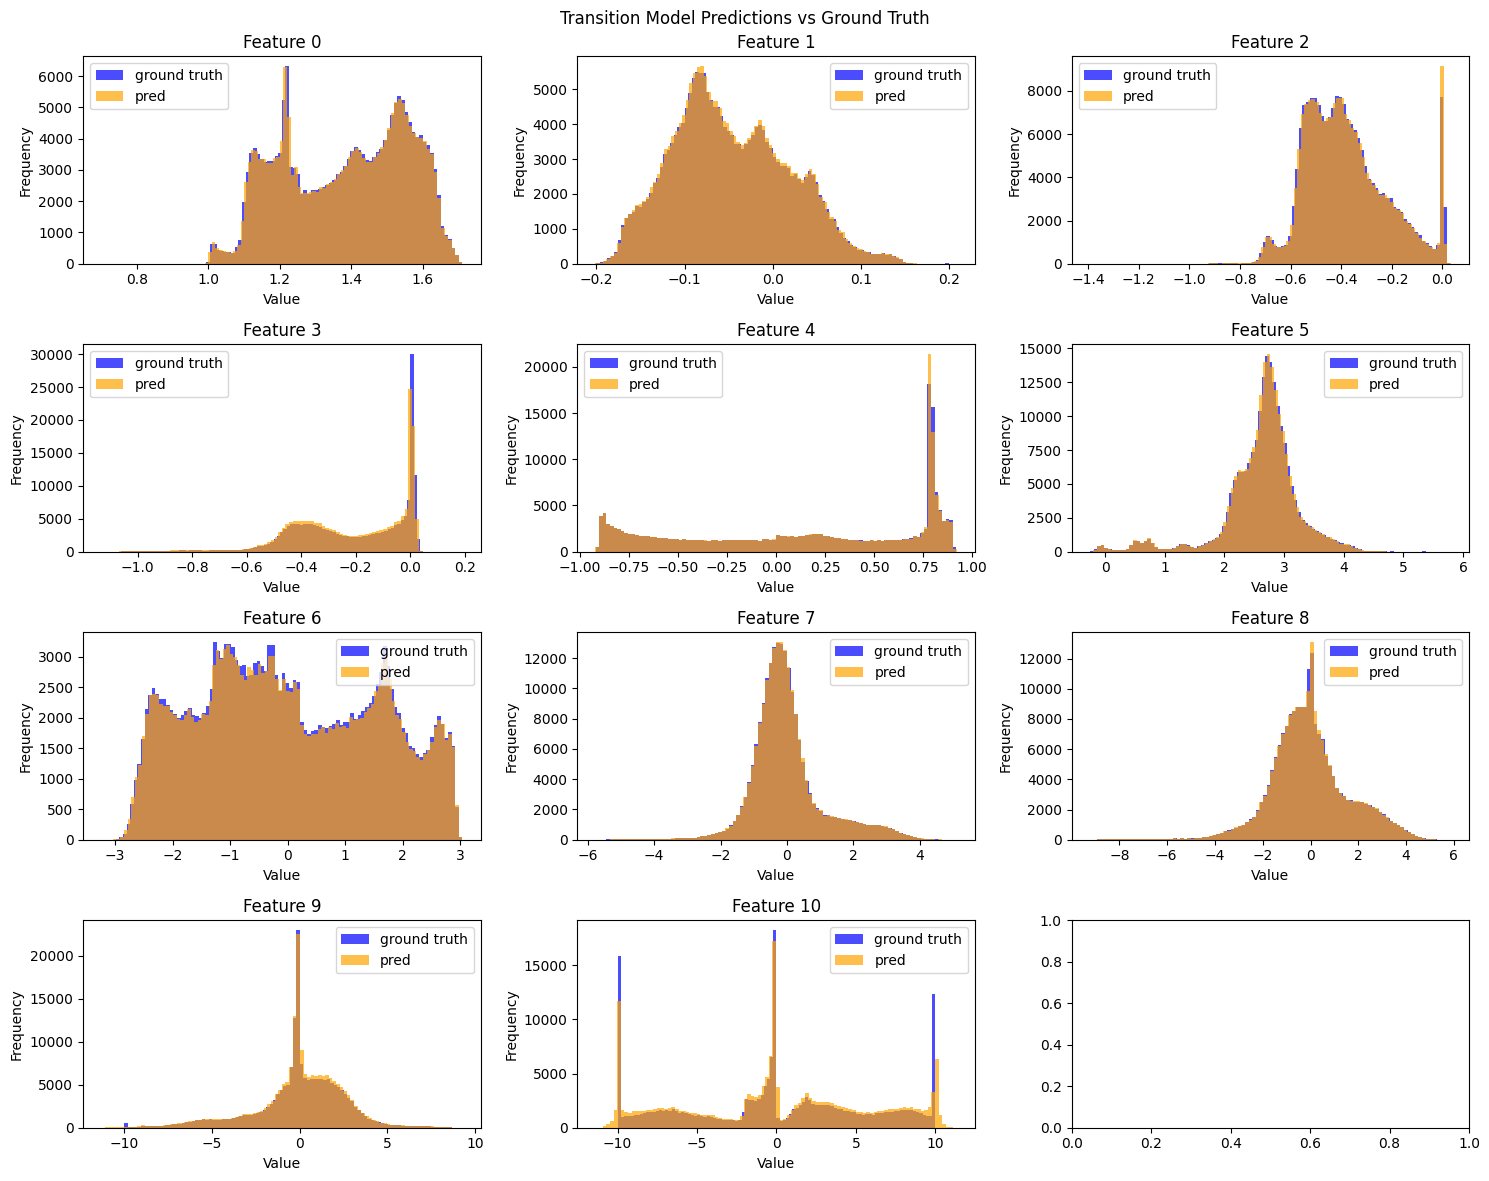

In [12]:
checkpoint = torch.load(f'saved_models/{env_name}/transition_model/dynamics_model_0.0.pt', map_location=device)
transition_model.model.load_state_dict(checkpoint['model_state_dict'])
transition_model.obs_normalizer = checkpoint['obs_normalizer']
transition_model.act_normalizer = checkpoint['act_normalizer']
pred, _ = get_eval(transition_model, eval_data)
plot_features(pred, eval_data['next_observations'], title='Transition Model Predictions vs Ground Truth')

/home/ubuntu/miniconda3/envs/mopo/lib/python3.8/site-packages/gym/envs/registration.py:505: UserWarning: WARN: The environment hopper-expert-v0 is out of date. You should consider upgrading to version `v2` with the environment ID `hopper-expert-v2`.
  logger.warn(
/home/ubuntu/miniconda3/envs/mopo/lib/python3.8/site-packages/d4rl/gym_mujoco/gym_envs.py:13: UserWarning: This environment is deprecated. Please use the most recent version of this environment.
  offline_env.OfflineEnv.__init__(self, **kwargs)
/home/ubuntu/miniconda3/envs/mopo/lib/python3.8/site-packages/gym/spaces/box.py:78: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


load datafile: 100%|██████████| 5/5 [00:00<00:00, 12.23it/s]


loaded dataset
Using device: cuda:0


/home/ubuntu/mbpo_uq/models/d4rl_world_model.py:167: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location=f'{self.device}')


Processed 3996 full batches + 1 partial batch of 7 samples.
— Total elements evaluated: 2197877
— Average MSE over all elements: 0.003139


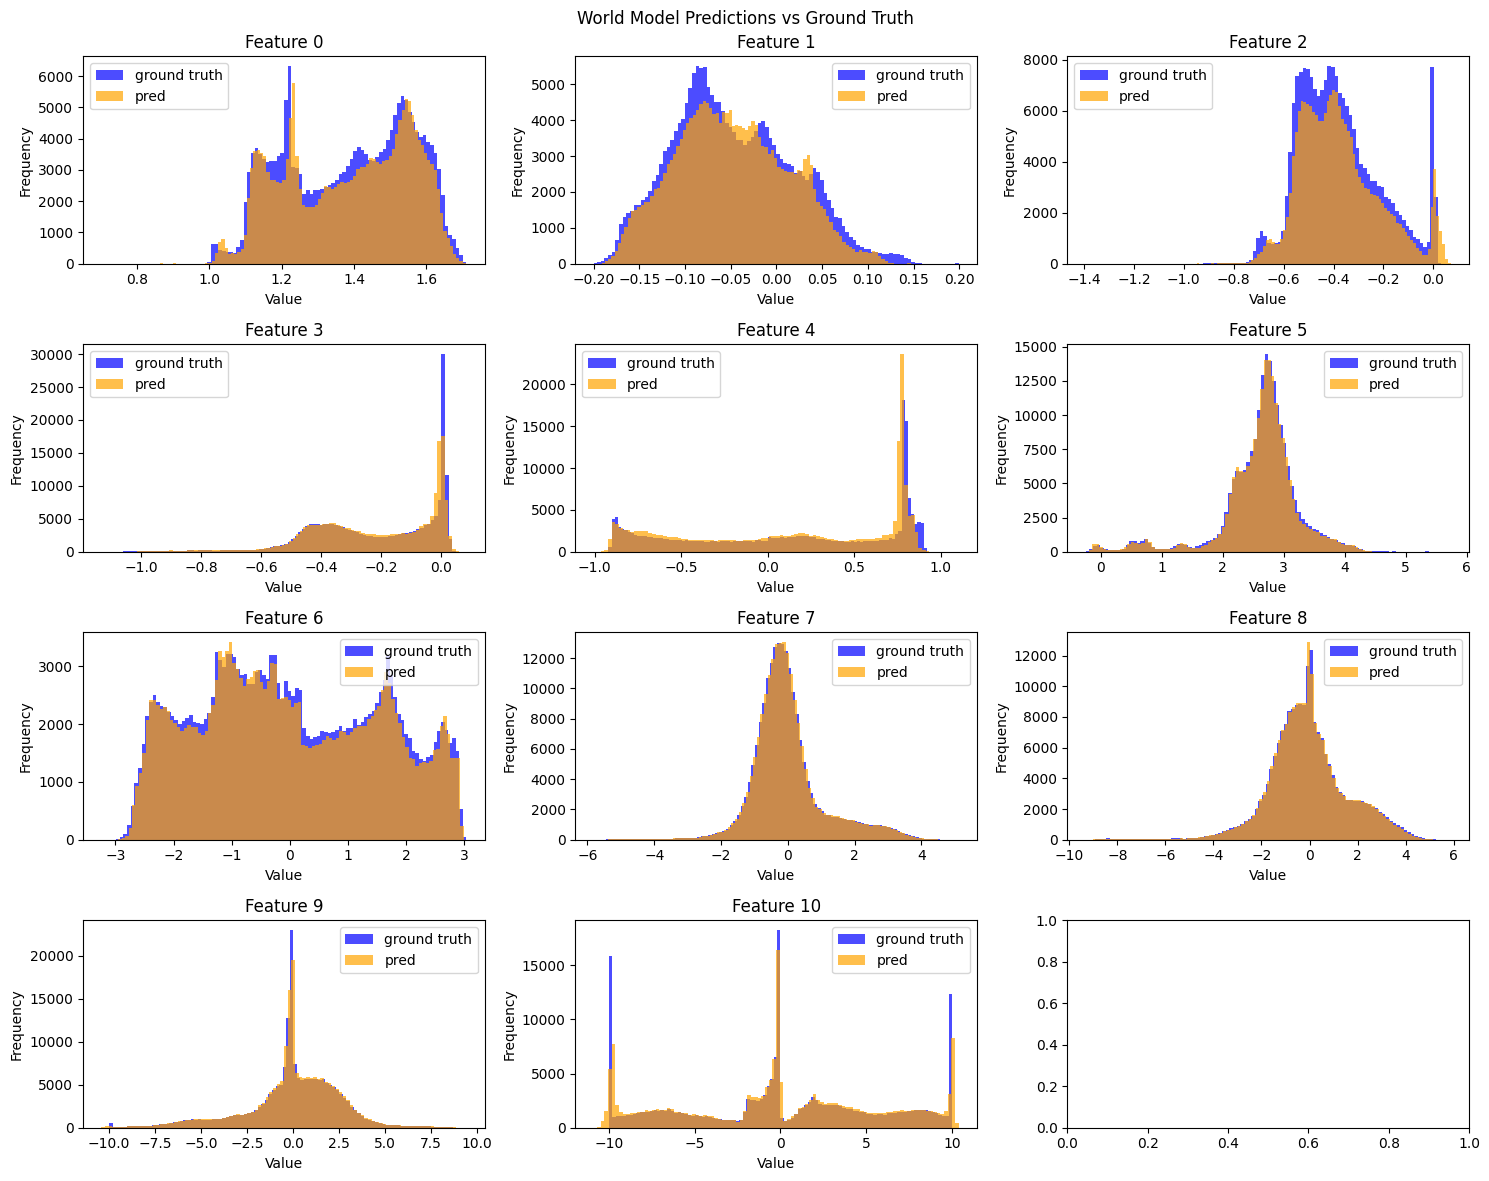

In [11]:
#hopper-expert
env_name = 'hopper-expert-v0'
world_model = D4RLWorldModel(env_name)
world_model.load_model(f'saved_models/hopper-expert-v0_noisy/world_model_0.01_0.0.pth')
pred,_ =  get_eval(world_model, eval_data, wm=True)
plot_features(pred, eval_data['next_observations'], title='World Model Predictions vs Ground Truth')

In [78]:
    #hopper-expert-noisy OLD
env_name = 'hopper-expert-v0'
world_model = D4RLWorldModel(env_name)
world_model.load_model(f'saved_models/hopper-expert-v0_noisy/world_model_0.05_0.05.pth')
predd = get_eval(world_model, eval_data, wm=True, noisy=True)

load datafile: 100%|██████████| 5/5 [00:00<00:00, 12.58it/s]


loaded dataset
Using device: cuda:0
Processed 3996 full batches + 1 partial batch of 7 samples.
— Total elements evaluated: 2197877
— Average MSE over all elements: 194386.504165


In [11]:
noise_list = [0.05,0.1,0.3,0.5, 0.6, 0.8]
wm_results = []
tm_results = []
wm_names = [
    "saved_models/hopper-expert-v0_noisy/world_model_0.06_0.05.pth",
    "saved_models/hopper-expert-v0_noisy/world_model_0.06_0.1.pth",
    "saved_models/hopper-expert-v0_noisy/world_model_0.05_0.3.pth",
    "saved_models/hopper-expert-v0_noisy/world_model_0.06_0.5.pth",
    "saved_models/hopper-expert-v0_noisy/world_model_0.06_0.6.pth",
    "saved_models/hopper-expert-v0_noisy/world_model_0.06_0.8.pth"

]
env_name = 'hopper-expert-v0'
env = gym.make(env_name)
dataset = d4rl.qlearning_dataset(env)
obs_shape = env.observation_space.shape
action_dim = np.prod(env.action_space.shape)   

offline_buffer = ReplayBuffer(
            buffer_size=len(dataset["observations"]),
        obs_shape=obs_shape,
        obs_dtype=np.float32,
        action_dim=action_dim,
        action_dtype=np.float32
    )

offline_buffer.load_dataset(dataset)
max_sample_size = offline_buffer.get_size
num_train_data = int(max_sample_size * (1.0 - params["holdout_ratio"]))
env_data = offline_buffer.sample_all()
eval_data = {}
for key in env_data.keys():
    eval_data[key] = env_data[key][num_train_data:]

world_model = D4RLWorldModel(env_name)
world_model.load_model(f'saved_models/hopper-expert-v0_noisy/world_model_0.01_0.0.pth')
pred, wm_mse_1 =  get_eval(world_model, eval_data, wm=True)

checkpoint = torch.load(f'saved_models/{env_name}/transition_model/dynamics_model_0.0.pt', map_location=device)
transition_model.model.load_state_dict(checkpoint['model_state_dict'])
transition_model.obs_normalizer = checkpoint['obs_normalizer']
transition_model.act_normalizer = checkpoint['act_normalizer']
pred, tm_mse_1 = get_eval(transition_model, eval_data)

#append first results
wm_results.append(wm_mse_1)
tm_results.append(tm_mse_1)
i = 0
for n in noise_list:
    #load data
    env_name  = 'hopper-expert-v0'
    data_path = f"/abiomed/intermediate_data_d4rl/hopper-expert-v0_noisy_{n}_unnorm.pkl"
    with open(data_path, 'rb') as f:
        dataset = pickle.load(f)
    obs_shape = env.observation_space.shape
    action_dim = np.prod(env.action_space.shape)   

    offline_buffer = ReplayBuffer(
                buffer_size=len(dataset["observations"]),
            obs_shape=obs_shape,
            obs_dtype=np.float32,
            action_dim=action_dim,
            action_dtype=np.float32
        )

    offline_buffer.load_dataset(dataset)
    max_sample_size = offline_buffer.get_size
    num_train_data = int(max_sample_size * (1.0 - params["holdout_ratio"]))
    env_data = offline_buffer.sample_all()
    eval_data = {}
    for key in env_data.keys():
        eval_data[key] = env_data[key][num_train_data:]


    #load world model
    with open(wm_names[i], 'rb') as f:
        world_model = D4RLWorldModel(env_name)
        world_model.load_model(f)
    
    #load transition model
    env_name2 = env_name +"_noisy"
    checkpoint = torch.load(f'saved_models/{env_name2}/transition_model/dynamics_model_{n}.pt', map_location=device)
    transition_model.model.load_state_dict(checkpoint['model_state_dict'])
    transition_model.obs_normalizer = checkpoint['obs_normalizer']
    transition_model.act_normalizer = checkpoint['act_normalizer']
    
    # load_saved_model = transition_model.networks["model"]
    
    # load_saved_model.load_state_dict(torch.load(f'saved_models/{env_name2}/transition_model/dynamics_model_{n}.pt'))
    # transition_model.model = load_saved_model

    #evaluate both with get_eval function
    _, wm_mse = get_eval(world_model, eval_data, wm=True)
    _, tm_mse = get_eval(transition_model, eval_data, noisy=True)
    #append
    wm_results.append(wm_mse)
    tm_results.append(tm_mse)
    i += 1



/home/ubuntu/miniconda3/envs/mopo/lib/python3.8/site-packages/gym/envs/registration.py:505: UserWarning: WARN: The environment hopper-expert-v0 is out of date. You should consider upgrading to version `v2` with the environment ID `hopper-expert-v2`.
  logger.warn(
/home/ubuntu/miniconda3/envs/mopo/lib/python3.8/site-packages/d4rl/gym_mujoco/gym_envs.py:13: UserWarning: This environment is deprecated. Please use the most recent version of this environment.
  offline_env.OfflineEnv.__init__(self, **kwargs)
/home/ubuntu/miniconda3/envs/mopo/lib/python3.8/site-packages/gym/spaces/box.py:78: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")
load datafile:   0%|          | 0/5 [00:00<?, ?it/s]

load datafile: 100%|██████████| 5/5 [00:00<00:00, 13.28it/s]


loaded dataset
Using device: cuda:0


/home/ubuntu/mbpo_uq/models/d4rl_world_model.py:167: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location=f'{self.device}')


Processed 3996 full batches + 1 partial batch of 7 samples.
— Total elements evaluated: 2197877
— Average MSE over all elements: 0.003139


...

loaded dataset
Using device: cuda:0
Processed 3996 full batches + 1 partial batch of 7 samples.
— Total elements evaluated: 2197877
— Average MSE over all elements: 0.056796
Processed 3996 full batches + 1 partial batch of 7 samples.
— Total elements evaluated: 2197877
— Average MSE over all elements: 0.069086


load datafile: 100%|██████████| 5/5 [00:00<00:00, 13.07it/s]


loaded dataset
Using device: cuda:0
Processed 3996 full batches + 1 partial batch of 7 samples.
— Total elements evaluated: 2197877
— Average MSE over all elements: 0.049342
Processed 3996 full batches + 1 partial batch of 7 samples.
— Total elements evaluated: 2197877
— Average MSE over all elements: 0.070677


load datafile: 100%|██████████| 5/5 [00:00<00:00, 13.12it/s]


loaded dataset
Using device: cuda:0
Processed 3996 full batches + 1 partial batch of 7 samples.
— Total elements evaluated: 2197877
— Average MSE over all elements: 0.052293
Processed 3996 full batches + 1 partial batch of 7 samples.
— Total elements evaluated: 2197877
— Average MSE over all elements: 0.074844


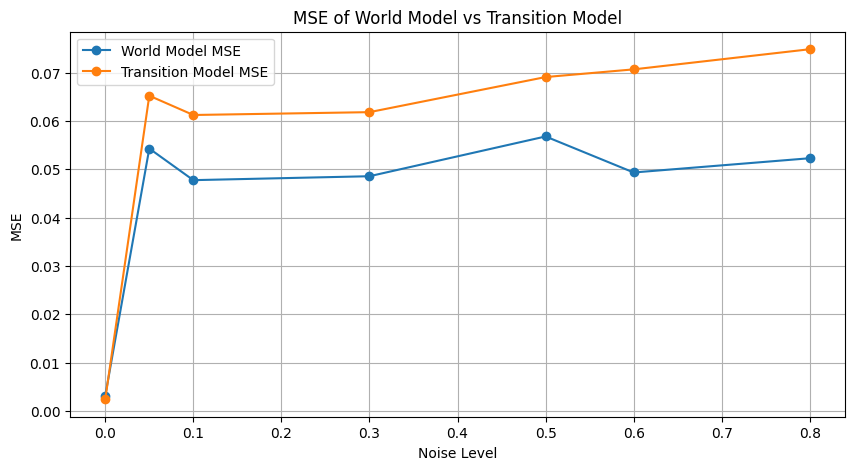

In [12]:
#plot them wm_results tm_results vs noise level
plt.figure(figsize=(10, 5))
plt.plot([0] + noise_list, wm_results, label='World Model MSE', marker='o')
plt.plot([0] + noise_list, tm_results, label='Transition Model MSE', marker='o')
plt.xlabel('Noise Level')
plt.ylabel('MSE')
plt.title('MSE of World Model vs Transition Model')
plt.legend()
plt.grid()

Processed 3996 full batches + 1 partial batch of 7 samples.
— Total elements evaluated: 2197877
— Average MSE over all elements: 0.069204


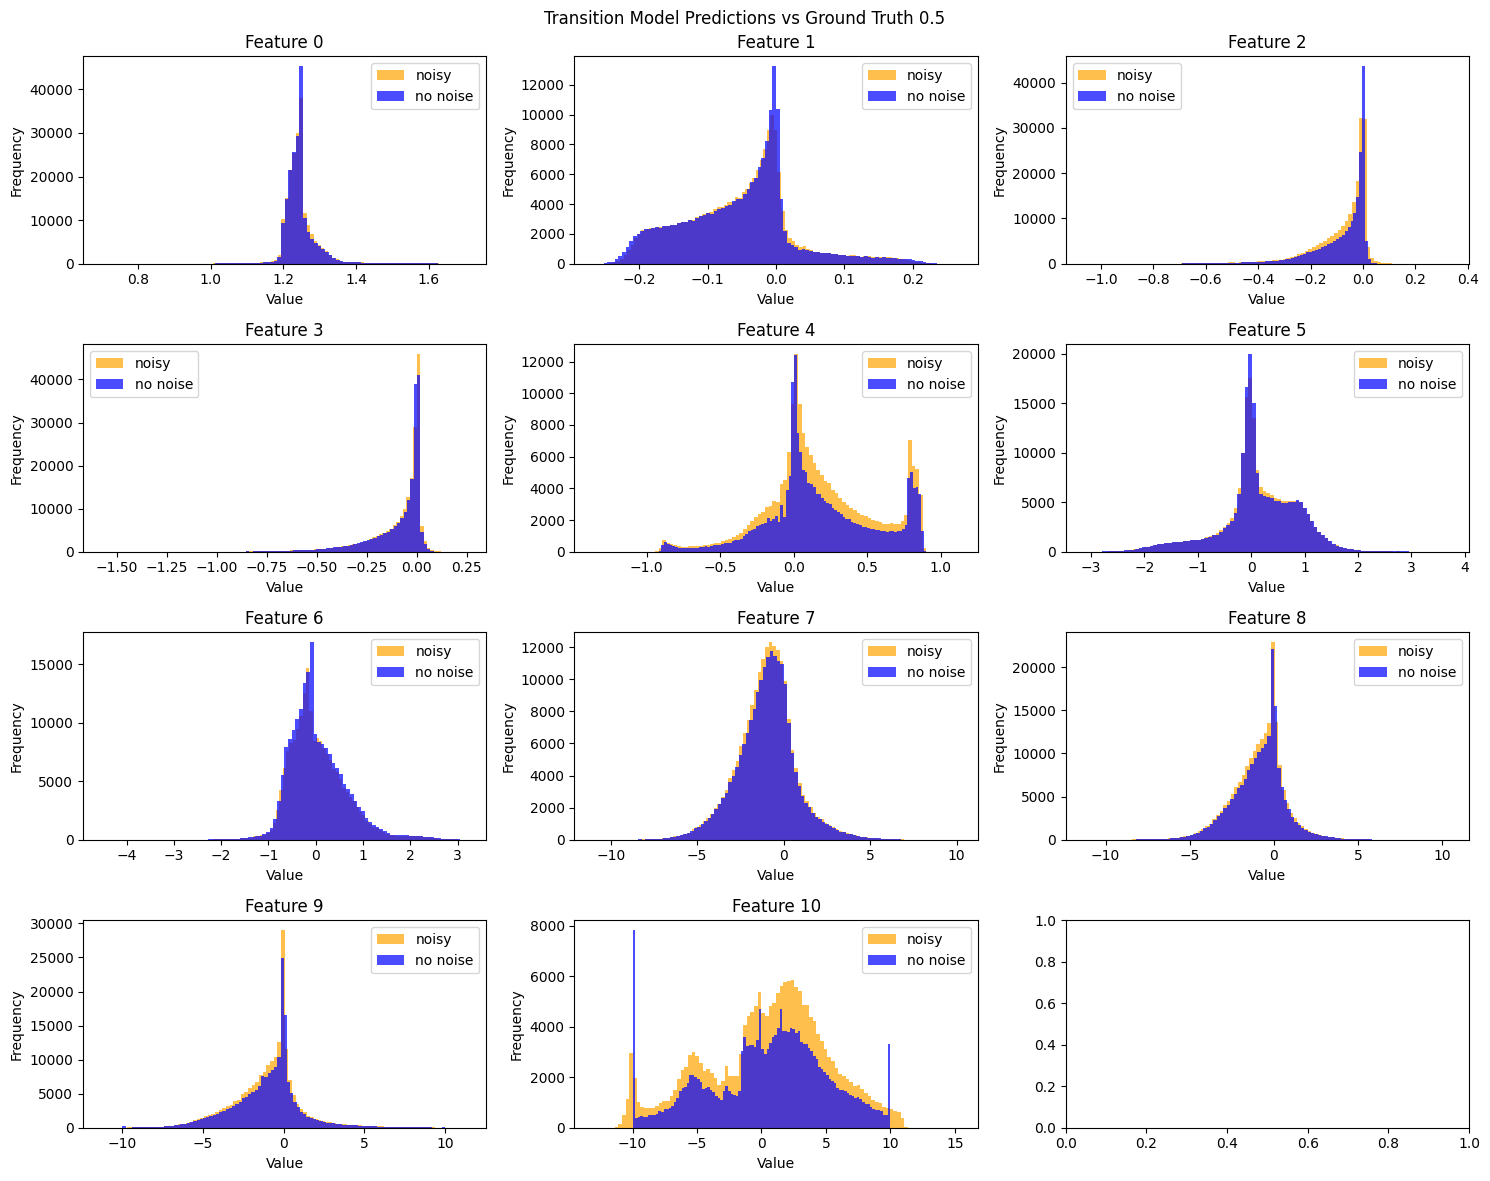

In [15]:
pred, _ = get_eval(transition_model, eval_data)
plot_features(pred, eval_data['next_observations'], title='Transition Model Predictions vs Ground Truth 0.5')

Processed 3996 full batches + 1 partial batch of 7 samples.
— Total elements evaluated: 2197877
— Average MSE over all elements: 0.043047


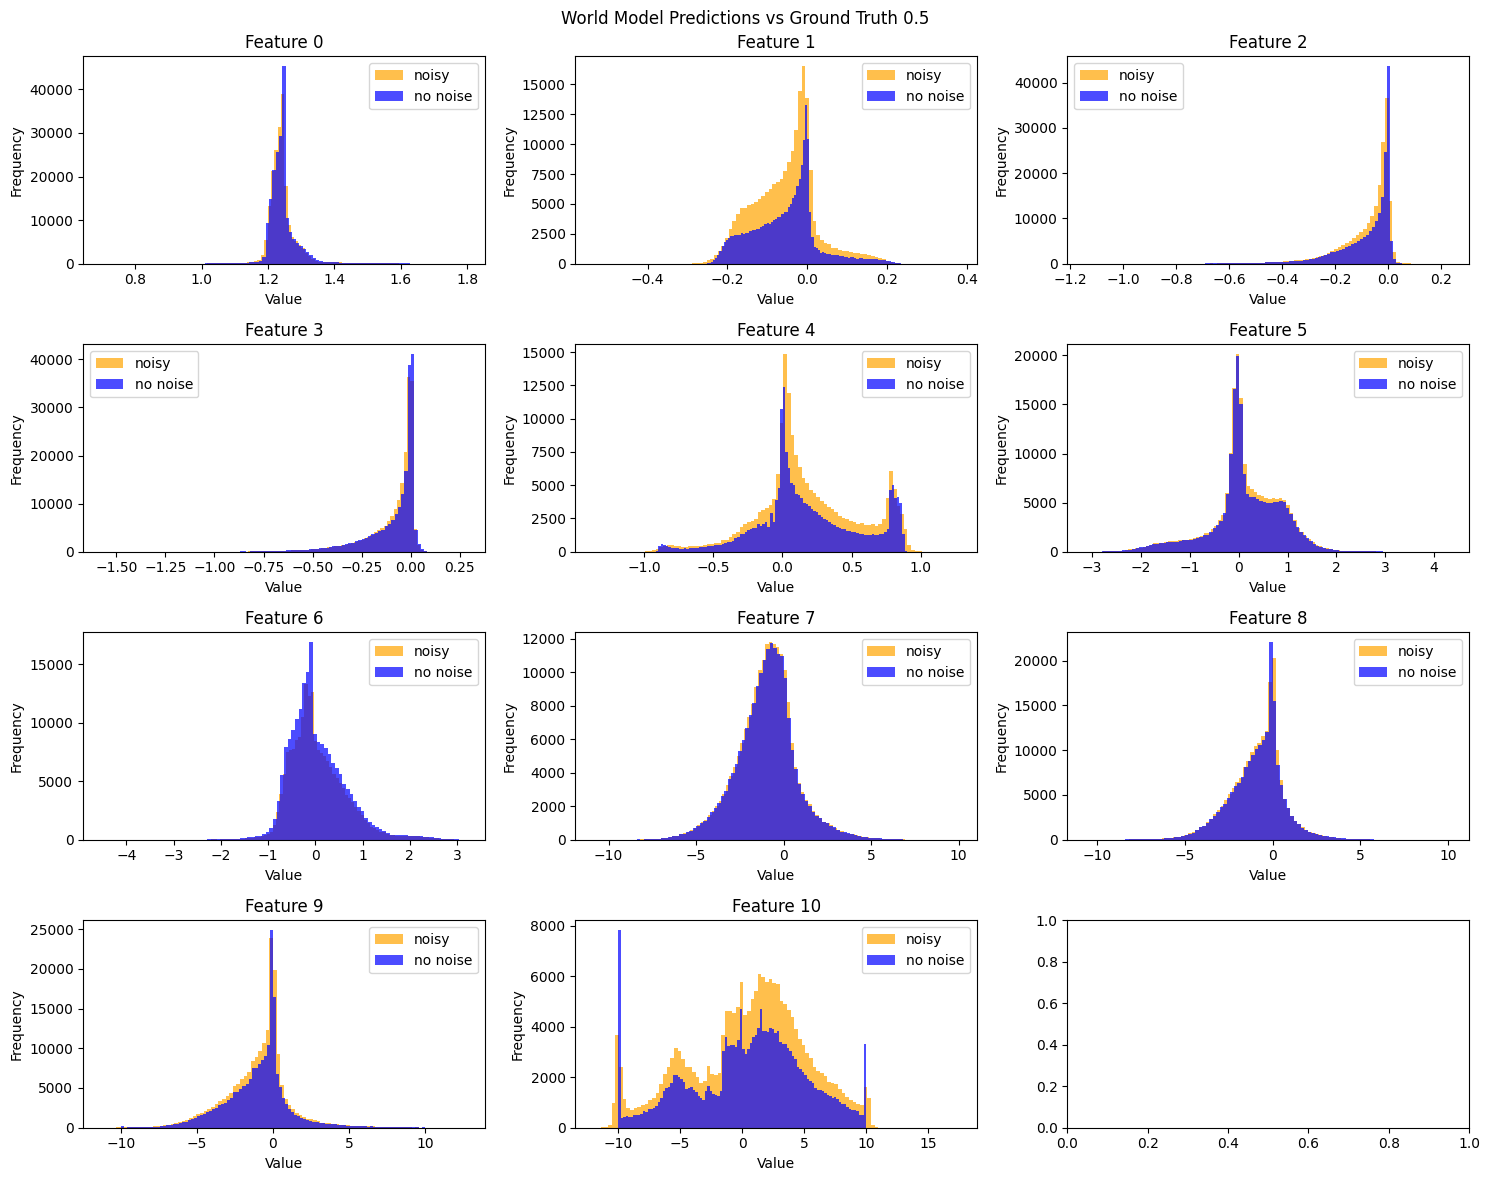

In [17]:
pred, _ = get_eval(world_model, eval_data, wm= True)
plot_features(pred, eval_data['next_observations'], title='World Model Predictions vs Ground Truth 0.5')

# CRPS calculation

In [14]:
def get_crps_list(env_name, data, model, device, batch_size=50, num_samples=50):

    print(f"Starting CRPS list for {env_name}")
    model.model.to(device)
    crps_list = []
    total_batches = len(data['observations']) // batch_size
    # data['observations'] = data['observations'][:51]
    # data['actions'] = data['actions'][:51]
    # data['next_observations'] = data['next_observations'][:51]
    # data['terminals'] = data['terminals'][:51]
    # data['rewards'] = data['rewards'][:51]

    with torch.no_grad():
        for i in tqdm.tqdm(range(total_batches)):
            state = data['observations'][i*batch_size:(i+1)*batch_size]
            action = data['actions'][i*batch_size:(i+1)*batch_size]
            next_state = data['next_observations'][i*batch_size:(i+1)*batch_size]

            states = np.repeat(state, num_samples, axis=0)
            actions = np.repeat(action, num_samples, axis=0)

            pred_input = torch.FloatTensor(np.concatenate([states, actions], axis=1)).to(device)
            
            model_pred = model.model(pred_input).cpu().numpy()
            
            # make it stop at the right length
            for i in range(batch_size):
                crps = crps_evaluation(model_pred[i * num_samples:(i+1) * num_samples], next_state[i])
                crps_list.append(crps.mean())

        # last batch
        if total_batches*batch_size < len(data['observations']):
            state = data['observations'][total_batches*batch_size:]
            action = data['actions'][total_batches*batch_size:]
            next_state = data['next_observations'][total_batches*batch_size:]

            states = np.repeat(state, num_samples, axis=0)
            actions = np.repeat(action, num_samples, axis=0)

            pred_input = torch.FloatTensor(np.concatenate([states, actions], axis=1)).to(device)
            # print("pred_input shape:", pred_input.shape)
            model_pred = model.model(pred_input).cpu().numpy()

            for i in range(state.shape[0]):
                crps = crps_evaluation(model_pred[i * num_samples:(i+1) * num_samples], next_state[i])
                crps_list.append(crps.mean())

    crps_list = np.array(crps_list)
    print(crps_list.shape)

    print("MEAN CRPS OVER SAMPLES:", crps_list.mean())
    # verify crps_list is the same length as the dataset
    assert len(crps_list) == len(data['observations']), "crps_list is not the same length as the dataset"
    return crps_list.mean()
    


In [15]:
noise_list = [0.05,0.1,0.3,0.5, 0.6, 0.8]
wm_results = []
wm_names = [
    "saved_models/hopper-expert-v0_noisy/world_model_0.06_0.05.pth",
    "saved_models/hopper-expert-v0_noisy/world_model_0.06_0.1.pth",
    "saved_models/hopper-expert-v0_noisy/world_model_0.05_0.3.pth",
    "saved_models/hopper-expert-v0_noisy/world_model_0.06_0.5.pth",
    "saved_models/hopper-expert-v0_noisy/world_model_0.06_0.6.pth",
    "saved_models/hopper-expert-v0_noisy/world_model_0.06_0.8.pth"
]
env_name = 'hopper-expert-v0'
env = gym.make(env_name)
dataset = d4rl.qlearning_dataset(env)
obs_shape = env.observation_space.shape
action_dim = np.prod(env.action_space.shape)   

offline_buffer = ReplayBuffer(
            buffer_size=len(dataset["observations"]),
        obs_shape=obs_shape,
        obs_dtype=np.float32,
        action_dim=action_dim,
        action_dtype=np.float32
    )

offline_buffer.load_dataset(dataset)
max_sample_size = offline_buffer.get_size
num_train_data = int(max_sample_size * (1.0 - params["holdout_ratio"]))
env_data = offline_buffer.sample_all()
eval_data = {}
for key in env_data.keys():
    eval_data[key] = env_data[key][num_train_data:]
world_model = D4RLWorldModel(env_name)
world_model.load_model(f'saved_models/hopper-expert-v0_noisy/world_model_0.01_0.0.pth')
wm_mse_1 =  get_crps_list(env_name, eval_data, world_model, device, num_samples =7)

wm_results.append(wm_mse_1)
i = 0
for n in noise_list:
    #load data
    env_name  = 'hopper-expert-v0'
    data_path = f"/abiomed/intermediate_data_d4rl/hopper-expert-v0_noisy_{n}_unnorm.pkl"
    with open(data_path, 'rb') as f:
        dataset = pickle.load(f)
    obs_shape = env.observation_space.shape
    action_dim = np.prod(env.action_space.shape)   

    offline_buffer = ReplayBuffer(
                buffer_size=len(dataset["observations"]),
            obs_shape=obs_shape,
            obs_dtype=np.float32,
            action_dim=action_dim,
            action_dtype=np.float32
        )

    offline_buffer.load_dataset(dataset)
    max_sample_size = offline_buffer.get_size
    num_train_data = int(max_sample_size * (1.0 - params["holdout_ratio"]))
    env_data = offline_buffer.sample_all()
    eval_data = {}
    for key in env_data.keys():
        eval_data[key] = env_data[key][num_train_data:]


    #load world model
    with open(wm_names[i], 'rb') as f:
        world_model = D4RLWorldModel(env_name)
        world_model.load_model(f)
   

    #evaluate both with get_eval function
    crps = get_crps_list(env_name, eval_data, world_model, device, num_samples =7)

    #append
    wm_results.append(crps)
    i += 1



/home/ubuntu/miniconda3/envs/mopo/lib/python3.8/site-packages/gym/envs/registration.py:505: UserWarning: WARN: The environment hopper-expert-v0 is out of date. You should consider upgrading to version `v2` with the environment ID `hopper-expert-v2`.
  logger.warn(
/home/ubuntu/miniconda3/envs/mopo/lib/python3.8/site-packages/d4rl/gym_mujoco/gym_envs.py:13: UserWarning: This environment is deprecated. Please use the most recent version of this environment.
  offline_env.OfflineEnv.__init__(self, **kwargs)
/home/ubuntu/miniconda3/envs/mopo/lib/python3.8/site-packages/gym/spaces/box.py:78: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


load datafile: 100%|██████████| 5/5 [00:00<00:00, 12.34it/s]
/home/ubuntu/mbpo_uq/models/d4rl_world_model.py:167: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = 

loaded dataset
Using device: cuda:0
Starting CRPS list for hopper-expert-v0


100%|██████████| 3996/3996 [00:22<00:00, 175.23it/s]


(199807,)
MEAN CRPS OVER SAMPLES: 0.023203388


...

(199807,)
MEAN CRPS OVER SAMPLES: 0.049528927


load datafile: 100%|██████████| 5/5 [00:00<00:00,  5.89it/s]


loaded dataset
Using device: cuda:0
Starting CRPS list for hopper-expert-v0


100%|██████████| 3996/3996 [00:22<00:00, 175.42it/s]

(199807,)
MEAN CRPS OVER SAMPLES: 0.04959036


In [17]:
#normal
get_crps_list(env_name, eval_data, world_model, device, num_samples =7)


Starting CRPS list for hopper-expert-v0


100%|██████████| 3996/3996 [00:22<00:00, 179.13it/s]


pred_input shape: torch.Size([49, 14])
(199807,)
MEAN CRPS OVER SAMPLES: 0.033328284


In [17]:
def ensemble_predict_mult(model, obs, act):
    model_input = torch.FloatTensor(np.concatenate([obs, act], axis=1)).to(device)
    pred_diff_means, pred_diff_logvars = model.model.predict(model_input)
    pred_diff_means = pred_diff_means.detach().cpu().numpy()

    ensemble_model_stds = pred_diff_logvars.exp().sqrt().detach().cpu().numpy()
    pred_diff_means = pred_diff_means + np.random.normal(size=pred_diff_means.shape) * ensemble_model_stds    
    pred_diff_samples = pred_diff_means[:, :, :-1]

    next_obs = pred_diff_samples + obs
    return np.swapaxes(next_obs, 0, 1)

In [18]:
def get_crps_list_ensemble(env_name, data, model, device):

    print(f"Starting CRPS list for {env_name}")
    model.model.to(device)
    crps_list = []
    batch_size = 50
    total_batches = len(data['observations']) // batch_size
    num_samples = 7
    
    with torch.no_grad():
        for i in tqdm.tqdm(range(total_batches)):
            state = data['observations'][i*batch_size:(i+1)*batch_size]
            action = data['actions'][i*batch_size:(i+1)*batch_size]
            next_state = data['next_observations'][i*batch_size:(i+1)*batch_size]
            model_pred = ensemble_predict_mult(model, state, action)
                        
            # make it stop at the right length
            for i in range(batch_size):
                crps = crps_evaluation(model_pred[i], next_state[i])
                crps_list.append(crps.mean())

        # last batch
        print(total_batches*batch_size)
        if total_batches*batch_size < len(data['observations']):
            state = data['observations'][total_batches*batch_size:]
            action = data['actions'][total_batches*batch_size:]
            next_state = data['next_observations'][total_batches*batch_size:]

            model_pred = ensemble_predict_mult(model, state, action)
            for i in range(state.shape[0]):
                crps = crps_evaluation(model_pred[i], next_state[i])
                crps_list.append(crps.mean())

    crps_list = np.array(crps_list)
   

    print("MEAN CRPS OVER SAMPLES:", crps_list.mean())
    # verify crps_list is the same length as the dataset
    assert len(crps_list) == len(data['observations']), "crps_list is not the same length as the dataset"
    return crps_list.mean()
    


In [19]:
noise_list = [0.05,0.1,0.3,0.5, 0.6, 0.8]
tm_results = []

env_name = 'hopper-expert-v0'
env = gym.make(env_name)
dataset = d4rl.qlearning_dataset(env)
obs_shape = env.observation_space.shape
action_dim = np.prod(env.action_space.shape)   

offline_buffer = ReplayBuffer(
            buffer_size=len(dataset["observations"]),
        obs_shape=obs_shape,
        obs_dtype=np.float32,
        action_dim=action_dim,
        action_dtype=np.float32
    )

offline_buffer.load_dataset(dataset)
max_sample_size = offline_buffer.get_size
num_train_data = int(max_sample_size * (1.0 - params["holdout_ratio"]))
env_data = offline_buffer.sample_all()
eval_data = {}
for key in env_data.keys():
    eval_data[key] = env_data[key][num_train_data:]

checkpoint = torch.load(f'saved_models/{env_name}/transition_model/dynamics_model_0.0.pt', map_location=device)
transition_model.model.load_state_dict(checkpoint['model_state_dict'])
transition_model.obs_normalizer = checkpoint['obs_normalizer']
transition_model.act_normalizer = checkpoint['act_normalizer']
tm_mse_1 = get_crps_list_ensemble(env_name, eval_data, transition_model, device)

#append first results
tm_results.append(tm_mse_1)
i = 0
for n in noise_list:
    #load data
    env_name  = 'hopper-expert-v0'
    data_path = f"/abiomed/intermediate_data_d4rl/hopper-expert-v0_noisy_{n}_unnorm.pkl"
    with open(data_path, 'rb') as f:
        dataset = pickle.load(f)
    obs_shape = env.observation_space.shape
    action_dim = np.prod(env.action_space.shape)   

    offline_buffer = ReplayBuffer(
                buffer_size=len(dataset["observations"]),
            obs_shape=obs_shape,
            obs_dtype=np.float32,
            action_dim=action_dim,
            action_dtype=np.float32
        )

    offline_buffer.load_dataset(dataset)
    max_sample_size = offline_buffer.get_size
    num_train_data = int(max_sample_size * (1.0 - params["holdout_ratio"]))
    env_data = offline_buffer.sample_all()
    eval_data = {}
    for key in env_data.keys():
        eval_data[key] = env_data[key][num_train_data:]

    #load transition model
    env_name2 = env_name +"_noisy"
    checkpoint = torch.load(f'saved_models/{env_name2}/transition_model/dynamics_model_{n}.pt', map_location=device)
    transition_model.model.load_state_dict(checkpoint['model_state_dict'])
    transition_model.obs_normalizer = checkpoint['obs_normalizer']
    transition_model.act_normalizer = checkpoint['act_normalizer']
   
    #evaluate both with get_eval function
    crps = get_crps_list_ensemble(env_name, eval_data, transition_model, device)
    #append
    tm_results.append(crps)
    i += 1



load datafile: 100%|██████████| 5/5 [00:00<00:00, 12.75it/s]
/tmp/ipykernel_84793/3830300693.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(f's

Starting CRPS list for hopper-expert-v0


100%|██████████| 3996/3996 [00:29<00:00, 134.04it/s]


199800
MEAN CRPS OVER SAMPLES: 1.4518685120049215


/tmp/ipykernel_84793/3830300693.py:62: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(f'saved_models/{env_name2}/transition_model/dynamics_model_{n}.p

...

199800
MEAN CRPS OVER SAMPLES: 0.3573951747266589
Starting CRPS list for hopper-expert-v0


100%|██████████| 3996/3996 [00:29<00:00, 134.05it/s]


199800
MEAN CRPS OVER SAMPLES: 0.4544711344023634
Starting CRPS list for hopper-expert-v0


100%|██████████| 3996/3996 [00:29<00:00, 136.07it/s]

199800
MEAN CRPS OVER SAMPLES: 0.5121173186588373


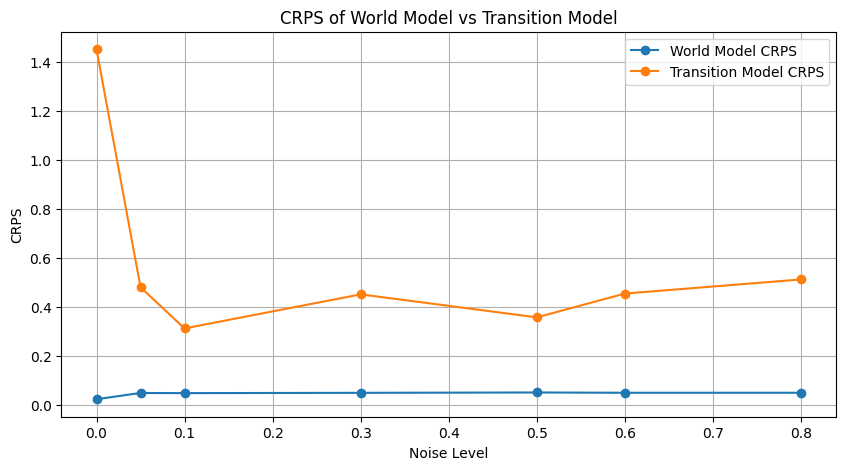

In [20]:
#plot them wm_results tm_results vs noise level
plt.figure(figsize=(10, 5))
plt.plot([0] + noise_list, wm_results, label='World Model CRPS', marker='o')
plt.plot([0] + noise_list, tm_results, label='Transition Model CRPS', marker='o')
plt.xlabel('Noise Level')
plt.ylabel('CRPS')
plt.title('CRPS of World Model vs Transition Model')
plt.legend()
plt.grid()

In [45]:
#normal
env = gym.make(env_name)
dataset = d4rl.qlearning_dataset(env)
obs_shape = env.observation_space.shape
action_dim = np.prod(env.action_space.shape)   

offline_buffer = ReplayBuffer(
            buffer_size=len(dataset["observations"]),
        obs_shape=obs_shape,
        obs_dtype=np.float32,
        action_dim=action_dim,
        action_dtype=np.float32
    )

offline_buffer.load_dataset(dataset)
max_sample_size = offline_buffer.get_size
num_train_data = int(max_sample_size * (1.0 - params["holdout_ratio"]))
env_data = offline_buffer.sample_all()
eval_data = {}
for key in env_data.keys():
    eval_data[key] = env_data[key][num_train_data:]
get_crps_list_ensemble(env_name, eval_data, transition_model, device)

load datafile: 100%|██████████| 5/5 [00:00<00:00, 13.04it/s]


Starting CRPS list for hopper-expert-v0


100%|██████████| 3996/3996 [00:27<00:00, 145.75it/s]

199800
MEAN CRPS OVER SAMPLES: 1.3128807520317192


1.3128807520317192